# Detecting Suspicious Financial Transactions Using Machine Learning

**Author:** Slavena Georgieva

---

## Abstract

*This section will be completed after the experiments and model evaluation have been finalized.*

---

# 1. Introduction

Financial institutions process millions of financial transactions every day, making manual monitoring for suspicious activity increasingly difficult. Anti-Money Laundering (AML) systems are designed to identify transactions that may indicate money laundering, terrorist financing, or other financial crimes. Traditionally, financial institutions rely on rule-based transaction monitoring systems, where predefined rules generate alerts for further investigation.

Although rule-based systems are effective for detecting known suspicious patterns, they often produce a large number of false positives and may fail to detect new or evolving money laundering techniques. As financial transactions continue to increase in volume and complexity, machine learning has emerged as a promising approach for improving transaction monitoring by learning patterns directly from historical data.

This project investigates the use of supervised machine learning algorithms to classify financial transactions as suspicious or non-suspicious using the SAML-D synthetic transaction monitoring dataset. Several classification models are trained and compared to determine which algorithm performs best for AML transaction monitoring. The project also demonstrates the complete machine learning workflow, including data preprocessing, feature engineering, dimensionality reduction, model training and performance evaluation.

---

# 2. Project Objectives

The main objectives of this project are:

- To explore and understand the characteristics of financial transaction data.
- To perform exploratory data analysis (EDA) and identify important data patterns.
- To preprocess and prepare the dataset for machine learning.
- To prepare a representative dataset suitable for machine learning while addressing the class imbalance
- To engineer additional features that may improve model performance.
- To compare multiple supervised machine learning algorithms for suspicious transaction classification.
- To evaluate the models using appropriate classification metrics such as Precision, Recall, F1-score and ROC-AUC.
- To identify the model that provides the best overall performance for supporting AML transaction monitoring.

---

# 3. Problem Statement

Money laundering is a major global financial crime, accounting for an estimated 2–5% of the world's Gross Domestic Product (GDP) each year. Financial institutions are required to monitor customer transactions and identify potentially suspicious activity that may require further investigation.

Traditional AML monitoring systems are primarily based on predefined business rules. While these systems are effective for detecting known scenarios, they often generate a high number of false positive alerts and may struggle to identify increasingly sophisticated laundering techniques.

The objective of this project is to investigate whether supervised machine learning models can improve the detection of suspicious financial transactions by learning complex patterns directly from historical labeled transaction data. Special attention is given to the extreme class imbalance that naturally exists in AML datasets, where suspicious transactions represent only a very small fraction of all transactions. The project evaluates different machine learning algorithms and compares their effectiveness in supporting transaction monitoring through accurate suspicious transaction classification.

---

# 4. Dataset

The choice of an appropriate dataset is essential for developing a reliable machine learning model. This section introduces the SAML-D dataset used throughout the project and describes its main characteristics together with the sampling strategy applied before model development.


## 4.1 Dataset Overview

The dataset used in this project is the **Synthetic Transaction Monitoring Dataset for Anti-Money Laundering (SAML-D)**, a publicly available synthetic dataset designed to simulate realistic financial transactions for Anti-Money Laundering (AML) research and machine learning applications.

The dataset contains approximately **9.5 million financial transactions** generated to represent both legitimate and money laundering activity. Each transaction includes information such as transaction amount, payment type, currencies, timestamps, account identifiers and bank locations.

The target variable is **`Is_laundering`**, which indicates whether a transaction is labelled as a money laundering transaction (1) or a normal transaction (0).

---

## 4.2 Dataset Features

The dataset contains both numerical and categorical variables describing different characteristics of each financial transaction. The following table summarises the variables used in this project.

In [1]:
import pandas as pd

feature_description = pd.DataFrame({
    "Feature": [
        "Time",
        "Date",
        "Sender_account",
        "Receiver_account",
        "Amount",
        "Payment_currency",
        "Received_currency",
        "Sender_bank_location",
        "Receiver_bank_location",
        "Payment_type",
        "Is_laundering",
        "Laundering_type"
    ],
    "Description": [
        "Transaction time",
        "Transaction date",
        "Sender account identifier",
        "Receiver account identifier",
        "Transaction amount",
        "Payment currency",
        "Received currency",
        "Sender bank location",
        "Receiver bank location",
        "Payment method",
        "Target variable indicating whether the transaction is related to money laundering",
        "Money laundering typology"
    ]
})

feature_description

,Feature,Description
0,Time,Transaction time
1,Date,Transaction date
2,Sender_account,Sender account identifier
3,Receiver_account,Receiver account identifier
4,Amount,Transaction amount
5,Payment_currency,Payment currency
6,Received_currency,Received currency
7,Sender_bank_location,Sender bank location
8,Receiver_bank_location,Receiver bank location
9,Payment_type,Payment method


The dataset contains a combination of numerical and categorical variables describing transaction characteristics. The target variable, **Is_laundering**, will be used for supervised classification.

## 4.3 Sampling Strategy

The original SAML-D dataset is highly imbalanced, containing approximately **9.5 million transactions**, of which only **9,873** are labelled as laundering transactions.

Training machine learning models directly on the complete dataset would require considerably more computational resources while providing little additional benefit for this project.

Therefore, a representative sample dataset was created by retaining **all 9,873 laundering transactions** and randomly selecting **190,000 normal transactions**. This produced a final dataset containing **199,873 transactions**, providing a substantially improved class distribution while preserving realistic transaction characteristics for machine learning experiments.

In [2]:
sampling_summary = pd.DataFrame({
    "Dataset": [
        "Original dataset",
        "Laundering transactions",
        "Sampled normal transactions",
        "Final sample dataset"
    ],
    "Transactions": [
        9504852,
        9873,
        190000,
        199873
    ]
})

sampling_summary

,Dataset,Transactions
0,Original dataset,9504852
1,Laundering transactions,9873
2,Sampled normal transactions,190000
3,Final sample dataset,199873


# 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to better understand the structure, quality and characteristics of the sampled dataset before applying machine learning algorithms.

The purpose of this stage is to identify potential data quality issues, understand feature distributions and explore relationships between variables that may influence model performance.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

# Improve plot appearance
plt.style.use("ggplot")

In [4]:
# Load the sampled dataset

df = pd.read_csv("AML_sample.csv")

In [5]:
# Display dataset dimensions

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 199,873
Columns: 12


In [6]:
# Display the first five records

df.head()

,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type
0,19:28:16,2023-05-09,371655141,8045939247,3792.25,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Small_Fan_Out
1,01:11:53,2023-08-01,1500297496,440699172,345.53,UK pounds,UK pounds,UK,UK,Credit card,0,Normal_Small_Fan_Out
2,11:19:15,2023-08-03,7775860537,7197849283,10128.69,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_Out
3,12:45:12,2023-06-09,3082029687,8404200332,18342.06,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Fan_In
4,04:44:01,2023-06-29,1179981989,8202066258,2345.67,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Group


## 5.2 Dataset Overview

The sampled dataset contains both legitimate and laundering transactions together with several numerical and categorical features describing different aspects of each financial transaction.

Before building machine learning models, it is important to examine the overall structure of the dataset and verify that the data has been loaded correctly.

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 199873 entries, 0 to 199872
Data columns (total 12 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Time                    199873 non-null  str    
 1   Date                    199873 non-null  str    
 2   Sender_account          199873 non-null  int64  
 3   Receiver_account        199873 non-null  int64  
 4   Amount                  199873 non-null  float64
 5   Payment_currency        199873 non-null  str    
 6   Received_currency       199873 non-null  str    
 7   Sender_bank_location    199873 non-null  str    
 8   Receiver_bank_location  199873 non-null  str    
 9   Payment_type            199873 non-null  str    
 10  Is_laundering           199873 non-null  int64  
 11  Laundering_type         199873 non-null  str    
dtypes: float64(1), int64(3), str(8)
memory usage: 18.3 MB


**Observation**

The sampled dataset contains 199,873 observations and 12 variables. The dataset includes both numerical and categorical features, and all variables appear to have complete observations.

In [8]:
df.describe()

,Sender_account,Receiver_account,Amount,Is_laundering
count,1.998730e+05,1.998730e+05,1.998730e+05,199873.000000
mean,5.017235e+09,5.008801e+09,1.037462e+04,0.049396
std,2.881320e+09,2.886468e+09,9.594040e+04,0.216695
min,6.154900e+04,1.326600e+04,7.620000e+00,0.000000
25%,2.536172e+09,2.511292e+09,2.179530e+03,0.000000
50%,5.014125e+09,5.002957e+09,6.070920e+03,0.000000
75%,7.507463e+09,7.517524e+09,1.046119e+04,0.000000
max,9.999759e+09,9.999900e+09,1.261850e+07,1.000000


**Observation**

The descriptive statistics indicate substantial variability in transaction amounts, with a wide range between minimum and maximum values. This suggests the presence of large transactions that may require further investigation during exploratory data analysis.

## 5.3 Missing Values

Missing values can negatively affect machine learning models and may require additional preprocessing. Therefore, the dataset is examined to determine whether any variables contain missing observations.

In [9]:
# Check for missing values

missing_values = df.isnull().sum()

missing_values

Time                      0
Date                      0
Sender_account            0
Receiver_account          0
Amount                    0
Payment_currency          0
Received_currency         0
Sender_bank_location      0
Receiver_bank_location    0
Payment_type              0
Is_laundering             0
Laundering_type           0
dtype: int64

In [10]:
missing_values[missing_values > 0]

Series([], dtype: int64)

**Observation**

No missing values were found in the sampled dataset. Therefore, no imputation or removal of missing observations is required.

## 5.4 Duplicate Records

Duplicate records may introduce bias into machine learning models. Therefore, the dataset is checked for duplicated transactions.

In [13]:
duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

Duplicate rows: 0


**Observation**

No duplicate records were identified in the sampled dataset.

## 5.5 Class Distribution

Understanding the class distribution is particularly important because AML datasets are naturally highly imbalanced. The following chart illustrates the distribution of normal and laundering transactions within the sampled dataset.

In [15]:
class_counts = df["Is_laundering"].value_counts()

class_counts

Is_laundering
0    190000
1      9873
Name: count, dtype: int64

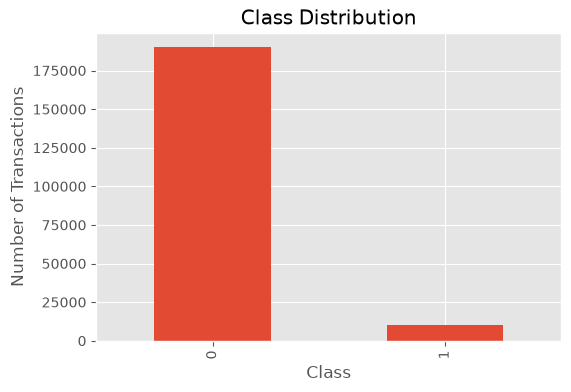

In [16]:
plt.figure(figsize=(6,4))

class_counts.plot(
    kind="bar"
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")

plt.show()

### Class Proportions

In [19]:
(class_counts / len(df) * 100).round(2)

Is_laundering
0    95.06
1     4.94
Name: count, dtype: float64

**Observation**

The sampled dataset remains imbalanced, although the class distribution is considerably improved compared to the original SAML-D dataset. All laundering transactions were retained, while a representative subset of normal transactions was selected to produce a dataset suitable for machine learning while preserving realistic characteristics.

## 5.6 Numerical Feature Analysis

The numerical features are analysed to understand their statistical properties, identify potential outliers and examine their distributions before building machine learning models.

Since the transaction amount is one of the most important variables in AML detection, it is analysed first.

In [20]:
# Summary statistics for transaction amount

df["Amount"].describe()

count    1.998730e+05
mean     1.037462e+04
std      9.594040e+04
min      7.620000e+00
25%      2.179530e+03
50%      6.070920e+03
75%      1.046119e+04
max      1.261850e+07
Name: Amount, dtype: float64

### Transaction Amount Distribution

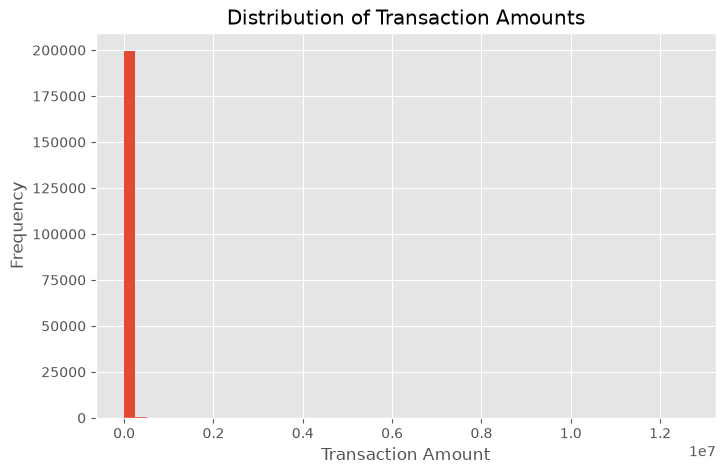

In [21]:
plt.figure(figsize=(8,5))

plt.hist(df["Amount"], bins=50)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

**Observation**

The transaction amount distribution is highly right-skewed. Most transactions involve relatively small amounts, while a small number of transactions have significantly larger values. This behaviour is typical for financial transaction datasets.

### Transaction Amount Boxplot

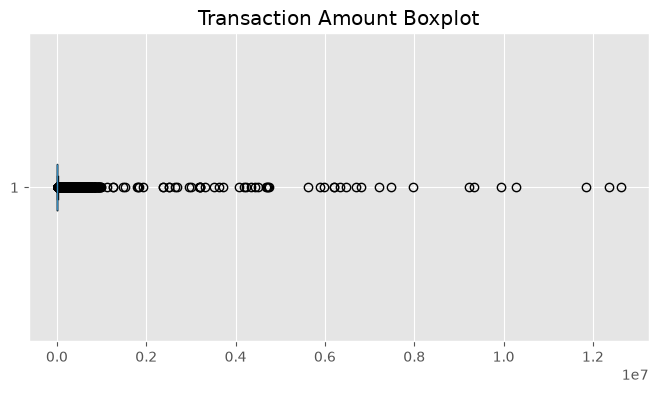

In [25]:
plt.figure(figsize=(8,4))

plt.boxplot(
    df["Amount"],
    orientation="horizontal"
)

plt.title("Transaction Amount Boxplot")

plt.show()

**Observation**

The boxplot confirms the presence of numerous extreme values. These observations are expected in financial datasets and may represent unusually large transactions rather than data errors.

### Transaction Amount by Class

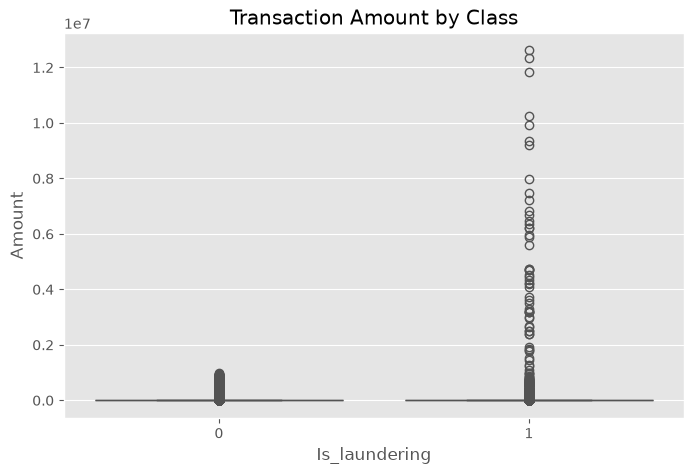

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Is_laundering",
    y="Amount",
    data=df
)

plt.title("Transaction Amount by Class")
plt.xlabel("Is_laundering")
plt.ylabel("Amount")

plt.show()

**Observation**

Comparing transaction amounts across the two classes helps determine whether laundering transactions generally involve different monetary values than normal transactions. Such differences may provide useful information for supervised machine learning models.

In [24]:
df.groupby("Is_laundering")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Is_laundering,,,,,,,,
0,190000.0,8804.658538,22433.140365,7.62,2144.2775,6110.24,10486.935000,981190.39
1,9873.0,40587.666906,419181.131445,15.82,2723.7900,5322.79,9789.673317,12618498.40


**Observation**

Laundering transactions exhibit considerably higher average transaction amounts than normal transactions. However, the overlap between the two classes indicates that transaction amount alone is unlikely to be sufficient for accurate classification, highlighting the importance of using multiple features in the machine learning models.

### 5.7 Payment Type Analysis

Payment type is an important transaction characteristic that may influence money laundering patterns. This section explores the distribution of different payment methods within the sampled dataset.

Understanding which payment methods occur most frequently provides useful context before building machine learning models.

In [26]:
payment_counts = df["Payment_type"].value_counts()

payment_counts

Payment_type
ACH                41565
Debit card         41458
Cheque             41328
Credit card        41274
Cross-border       21065
Cash Withdrawal     7337
Cash Deposit        5846
Name: count, dtype: int64

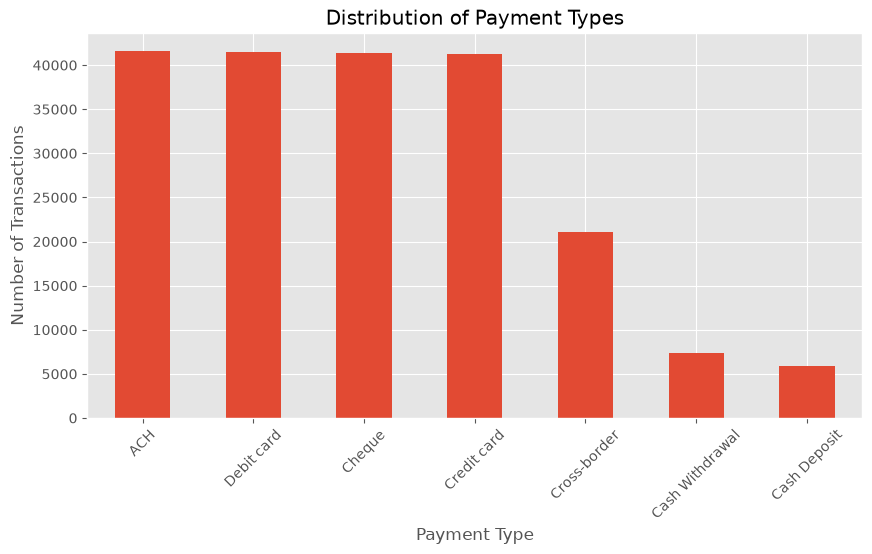

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

payment_counts.plot(
    kind="bar"
)

plt.title("Distribution of Payment Types")
plt.xlabel("Payment Type")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.show()

**Observation**

The dataset contains several payment methods, with some appearing substantially more frequently than others. This indicates that transaction activity is concentrated around a limited number of payment types, which may provide useful predictive information for machine learning models.

In [29]:
payment_percent = (payment_counts / len(df) * 100).round(2)

payment_percent.to_frame(name="Percentage (%)")

,Percentage (%)
Payment_type,
ACH,20.80
Debit card,20.74
Cheque,20.68
Credit card,20.65
Cross-border,10.54
Cash Withdrawal,3.67
Cash Deposit,2.92


**Observation**

Electronic payment methods (ACH, Debit Card, Credit Card and Cheque) account for approximately 83% of all transactions in the sampled dataset. Cross-border transfers represent around 10.5%, while cash-based transactions (Cash Deposit and Cash Withdrawal) occur less frequently. The distribution suggests that transaction activity is concentrated in a small number of payment methods, which may contribute useful predictive information during model training.

#### Payment Type by Transaction Class

The following analysis compares payment methods between legitimate and laundering transactions to identify whether certain payment methods are more frequently associated with suspicious activity.

In [30]:
payment_class = pd.crosstab(
    df["Payment_type"],
    df["Is_laundering"]
)

payment_class

Is_laundering,0,1
Payment_type,,
ACH,40406,1159
Cash Deposit,4441,1405
Cash Withdrawal,6003,1334
Cheque,40241,1087
Credit card,40138,1136
Cross-border,18437,2628
Debit card,40334,1124


<Figure size 1000x600 with 0 Axes>

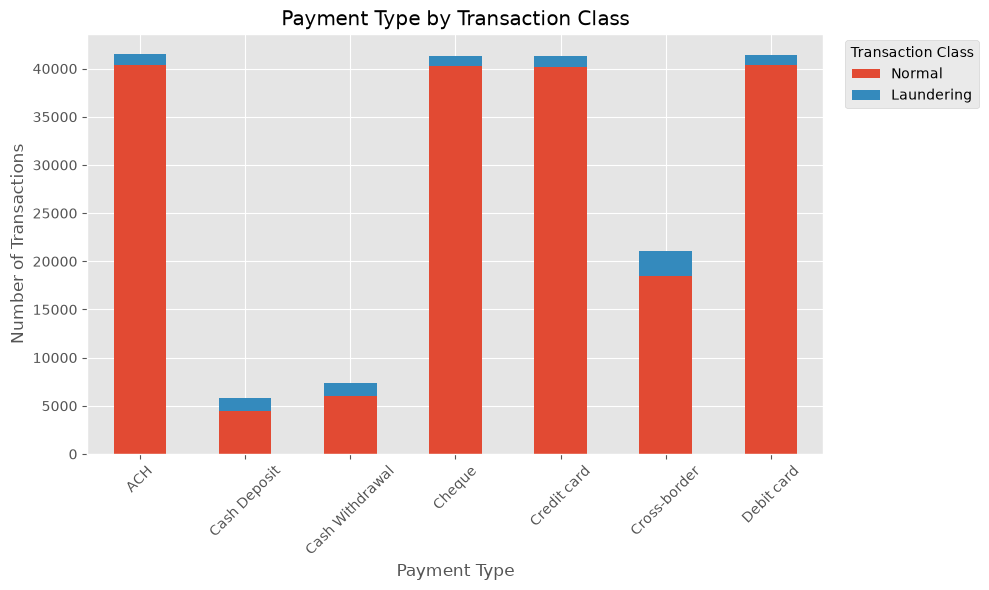

In [33]:
plt.figure(figsize=(10,6))

ax = payment_class.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Payment Type by Transaction Class")
plt.xlabel("Payment Type")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.legend(
    title="Transaction Class",
    labels=["Normal", "Laundering"],
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

**Observation**

Most payment methods are dominated by legitimate transactions, reflecting the class imbalance of the sampled dataset. However, cross-border transactions contain a noticeably larger number of laundering transactions compared to other payment methods, suggesting that payment method may provide useful predictive information for machine learning models.

In [32]:
laundering_rate = (
    payment_class.div(payment_class.sum(axis=1), axis=0) * 100
).round(2)

laundering_rate

Is_laundering,0,1
Payment_type,,
ACH,97.21,2.79
Cash Deposit,75.97,24.03
Cash Withdrawal,81.82,18.18
Cheque,97.37,2.63
Credit card,97.25,2.75
Cross-border,87.52,12.48
Debit card,97.29,2.71


**Observation**

The laundering rate varies considerably across payment methods. Cash Deposit exhibits the highest proportion of laundering transactions (24.03%), followed by Cash Withdrawal (18.18%) and Cross-border payments (12.48%). In contrast, ACH, Debit Card, Credit Card and Cheque transactions show substantially lower laundering rates, all below 3%.

These findings suggest that the payment method is an informative feature and may contribute to distinguishing legitimate from suspicious transactions in the machine learning models.

## 5.8 Currency Analysis

Transaction currency is an important characteristic that may reveal patterns associated with international financial activity.

This section examines the distribution of payment currencies and received currencies within the sampled dataset to better understand the structure of financial transactions before model development.

In [34]:
payment_currency = df["Payment_currency"].value_counts()

payment_currency

Payment_currency
UK pounds          190897
Euro                 2542
Turkish lira          645
Swiss franc           618
Dirham                614
Naira                 610
Pakistani rupee       607
Moroccan dirham       583
Mexican Peso          581
Albanian lek          558
Yen                   547
US dollar             543
Indian rupee          528
Name: count, dtype: int64

**Observation**

Most transactions are concentrated in a relatively small number of payment currencies. This reflects the composition of the synthetic dataset and provides useful information about transaction diversity.

In [35]:
(payment_currency / len(df) * 100).round(2)

Payment_currency
UK pounds          95.51
Euro                1.27
Turkish lira        0.32
Swiss franc         0.31
Dirham              0.31
Naira               0.31
Pakistani rupee     0.30
Moroccan dirham     0.29
Mexican Peso        0.29
Albanian lek        0.28
Yen                 0.27
US dollar           0.27
Indian rupee        0.26
Name: count, dtype: float64

In [36]:
payment_currency_class = pd.crosstab(
    df["Payment_currency"],
    df["Is_laundering"]
)

payment_currency_class

Is_laundering,0,1
Payment_currency,,
Albanian lek,494,64
Dirham,525,89
Euro,2282,260
Indian rupee,460,68
Mexican Peso,513,68
Moroccan dirham,493,90
Naira,548,62
Pakistani rupee,545,62
Swiss franc,536,82


<Figure size 1000x600 with 0 Axes>

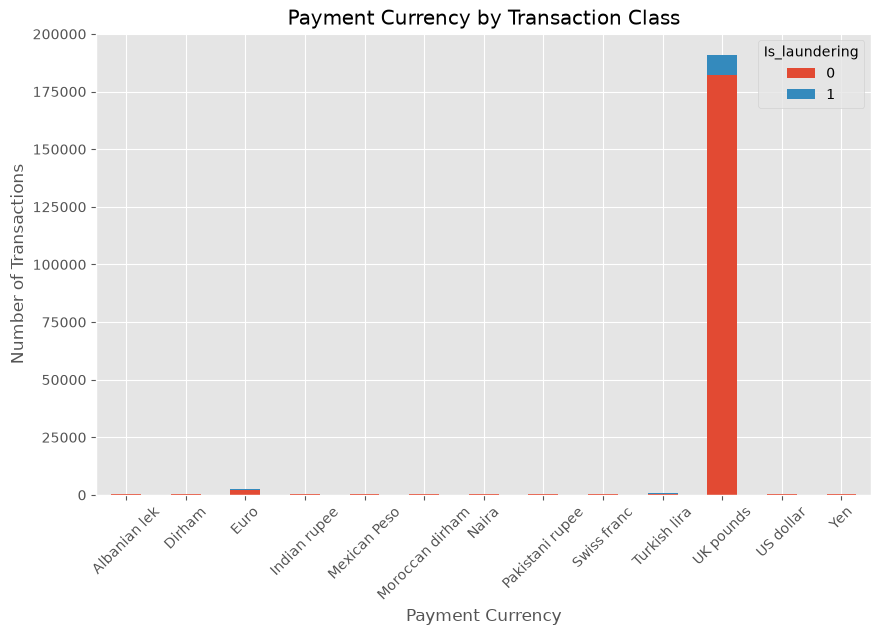

In [37]:
plt.figure(figsize=(10,6))

payment_currency_class.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Payment Currency by Transaction Class")
plt.xlabel("Payment Currency")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.show()

**Observation**

Legitimate transactions dominate every payment currency because they represent the majority of the sampled dataset. However, comparing the relative distribution helps identify currencies that may contain a higher proportion of suspicious activity.

In [38]:
payment_currency_rate = (
    payment_currency_class.div(payment_currency_class.sum(axis=1), axis=0) * 100
).round(2)

payment_currency_rate

Is_laundering,0,1
Payment_currency,,
Albanian lek,88.53,11.47
Dirham,85.50,14.50
Euro,89.77,10.23
Indian rupee,87.12,12.88
Mexican Peso,88.30,11.70
Moroccan dirham,84.56,15.44
Naira,89.84,10.16
Pakistani rupee,89.79,10.21
Swiss franc,86.73,13.27


**Observation**

Comparing laundering rates across payment currencies provides a clearer picture than absolute transaction counts. Currencies with relatively higher laundering rates may represent informative predictors during model training.

## 5.9 Received Currency Analysis

The received currency may differ from the payment currency in international or foreign exchange transactions.

This section examines the distribution of received currencies and investigates whether certain currencies appear more frequently in suspicious transactions.

In [39]:
received_currency = df["Received_currency"].value_counts()

received_currency

Received_currency
UK pounds          182595
Euro                 5313
Naira                1189
Albanian lek         1173
Mexican Peso         1166
Moroccan dirham      1160
Pakistani rupee      1098
Dirham               1087
Turkish lira         1069
Yen                  1055
Indian rupee         1044
US dollar             976
Swiss franc           948
Name: count, dtype: int64

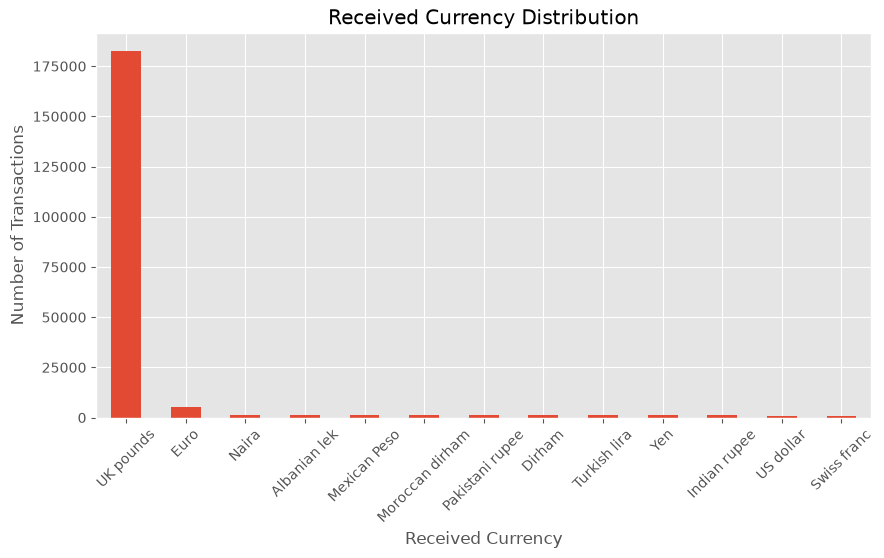

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

received_currency.plot(
    kind="bar"
)

plt.title("Received Currency Distribution")
plt.xlabel("Received Currency")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.show()

**Observation**

Most received transactions are concentrated in a relatively small number of currencies. This reflects the underlying distribution of financial activity within the sampled dataset.

In [41]:
(received_currency / len(df) * 100).round(2)

Received_currency
UK pounds          91.36
Euro                2.66
Naira               0.59
Albanian lek        0.59
Mexican Peso        0.58
Moroccan dirham     0.58
Pakistani rupee     0.55
Dirham              0.54
Turkish lira        0.53
Yen                 0.53
Indian rupee        0.52
US dollar           0.49
Swiss franc         0.47
Name: count, dtype: float64

**Observation**

The percentage distribution shows that only a few currencies dominate the dataset, while the remaining currencies occur much less frequently.

In [42]:
received_currency_class = pd.crosstab(
    df["Received_currency"],
    df["Is_laundering"]
)

received_currency_class

Is_laundering,0,1
Received_currency,,
Albanian lek,911,262
Dirham,862,225
Euro,4597,716
Indian rupee,872,172
Mexican Peso,931,235
Moroccan dirham,875,285
Naira,901,288
Pakistani rupee,894,204
Swiss franc,835,113


<Figure size 1000x600 with 0 Axes>

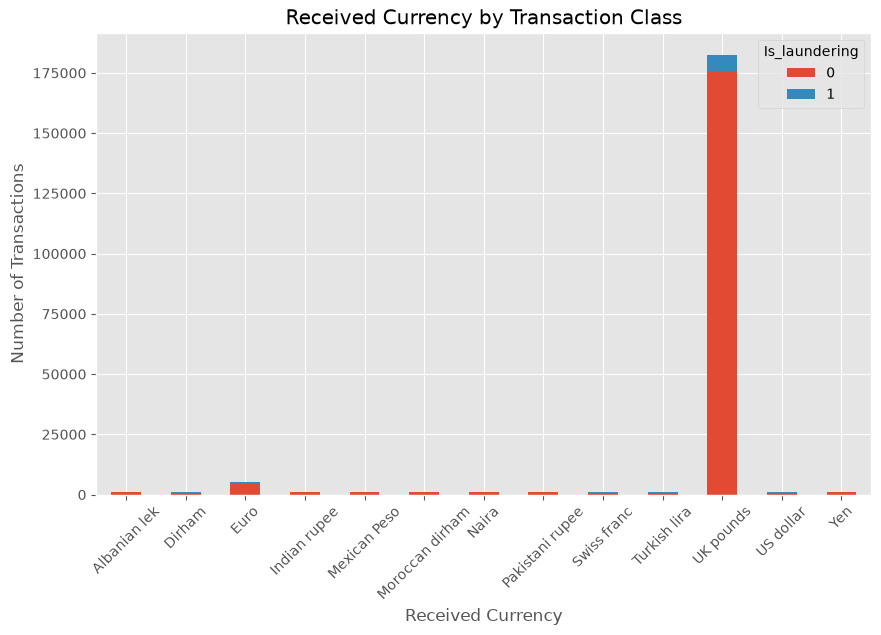

In [43]:
plt.figure(figsize=(10,6))

received_currency_class.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Received Currency by Transaction Class")
plt.xlabel("Received Currency")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.show()

**Observation**

Legitimate transactions represent the majority of observations across all received currencies. Nevertheless, comparing transaction classes provides insight into whether specific currencies contain relatively higher levels of suspicious activity.

In [44]:
received_currency_rate = (
    received_currency_class.div(received_currency_class.sum(axis=1), axis=0) * 100
).round(2)

received_currency_rate

Is_laundering,0,1
Received_currency,,
Albanian lek,77.66,22.34
Dirham,79.30,20.70
Euro,86.52,13.48
Indian rupee,83.52,16.48
Mexican Peso,79.85,20.15
Moroccan dirham,75.43,24.57
Naira,75.78,24.22
Pakistani rupee,81.42,18.58
Swiss franc,88.08,11.92


**Observation**

Evaluating laundering rates by received currency highlights currencies that may be more strongly associated with suspicious transactions. These differences may become useful predictive features for machine learning models.

## 5.10 Sender Bank Location Analysis

The geographical location of the sender's bank may provide valuable information about transaction patterns and potential money laundering behaviour.

This section explores the distribution of sender bank locations and compares their relationship with transaction classes.

In [45]:
sender_location = df["Sender_bank_location"].value_counts()

sender_location

Sender_bank_location
UK             192980
Turkey            459
Germany           450
Nigeria           446
Switzerland       445
Pakistan          432
UAE               425
Italy             418
Morocco           409
Austria           401
Albania           394
Spain             391
Mexico            391
France            379
India             376
Japan             370
USA               365
Netherlands       342
Name: count, dtype: int64

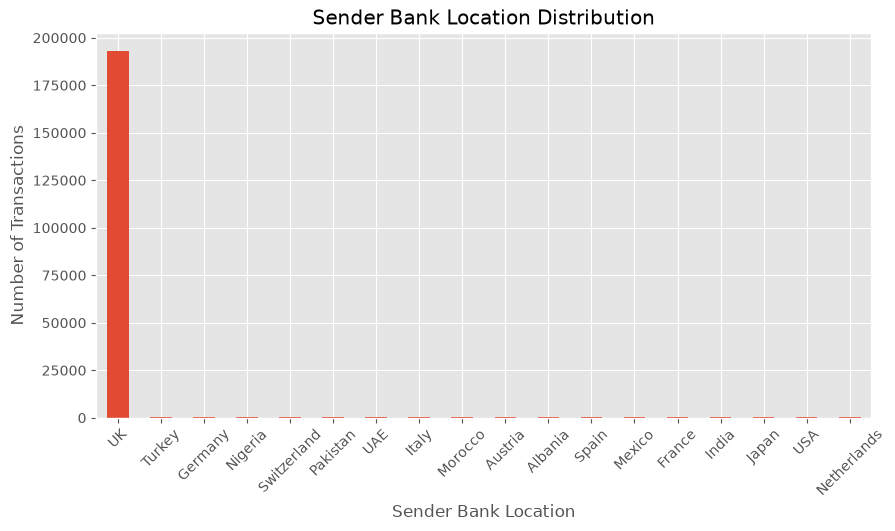

In [46]:
plt.figure(figsize=(10,5))

sender_location.plot(
    kind="bar"
)

plt.title("Sender Bank Location Distribution")
plt.xlabel("Sender Bank Location")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.show()

**Observation**

Most transactions originate from a relatively small number of sender bank locations. This reflects the geographical structure of the sampled dataset.

In [47]:
(sender_location / len(df) * 100).round(2)

Sender_bank_location
UK             96.55
Turkey          0.23
Germany         0.23
Nigeria         0.22
Switzerland     0.22
Pakistan        0.22
UAE             0.21
Italy           0.21
Morocco         0.20
Austria         0.20
Albania         0.20
Spain           0.20
Mexico          0.20
France          0.19
India           0.19
Japan           0.19
USA             0.18
Netherlands     0.17
Name: count, dtype: float64

**Observation**

The percentage distribution confirms that transaction activity is concentrated in only a few sender locations, while several locations contribute relatively few transactions.

In [48]:
sender_location_class = pd.crosstab(
    df["Sender_bank_location"],
    df["Is_laundering"]
)

sender_location_class

Is_laundering,0,1
Sender_bank_location,,
Albania,366,28
Austria,363,38
France,348,31
Germany,407,43
India,334,42
Italy,373,45
Japan,332,38
Mexico,347,44
Morocco,354,55


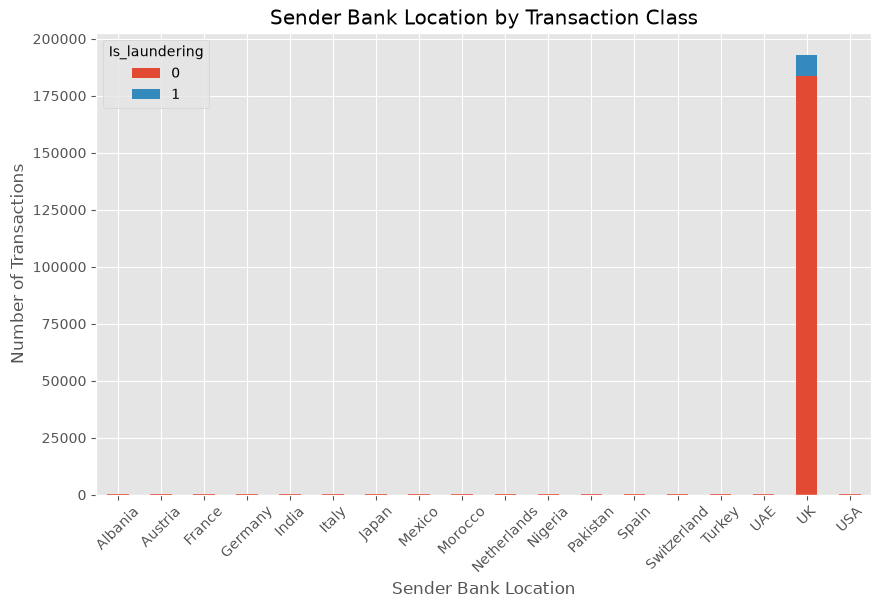

In [49]:
sender_location_class.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Sender Bank Location by Transaction Class")
plt.xlabel("Sender Bank Location")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.show()

**Observation**

Legitimate transactions dominate all sender bank locations. Nevertheless, some locations contain relatively higher proportions of suspicious transactions, suggesting potential geographical differences in laundering behaviour.

In [50]:
sender_location_rate = (
    sender_location_class.div(sender_location_class.sum(axis=1), axis=0) * 100
).round(2)

sender_location_rate

Is_laundering,0,1
Sender_bank_location,,
Albania,92.89,7.11
Austria,90.52,9.48
France,91.82,8.18
Germany,90.44,9.56
India,88.83,11.17
Italy,89.23,10.77
Japan,89.73,10.27
Mexico,88.75,11.25
Morocco,86.55,13.45


**Observation**

Comparing laundering rates across sender locations provides a more informative measure than transaction counts alone and may reveal useful predictive patterns.

## 5.11 Receiver Bank Location Analysis

Receiver bank location is another important geographical feature that may reveal differences between legitimate and suspicious financial activity.

This section examines where transaction funds are received and compares the class distribution across receiver locations.

In [51]:
receiver_location = df["Receiver_bank_location"].value_counts()

receiver_location

Receiver_bank_location
UK             184601
Nigeria          1009
Morocco          1001
Albania           994
Mexico            990
Austria           967
Pakistan          933
Turkey            921
UAE               909
Netherlands       899
Japan             875
Germany           868
India             856
Spain             825
Italy             824
France            821
USA               803
Switzerland       777
Name: count, dtype: int64

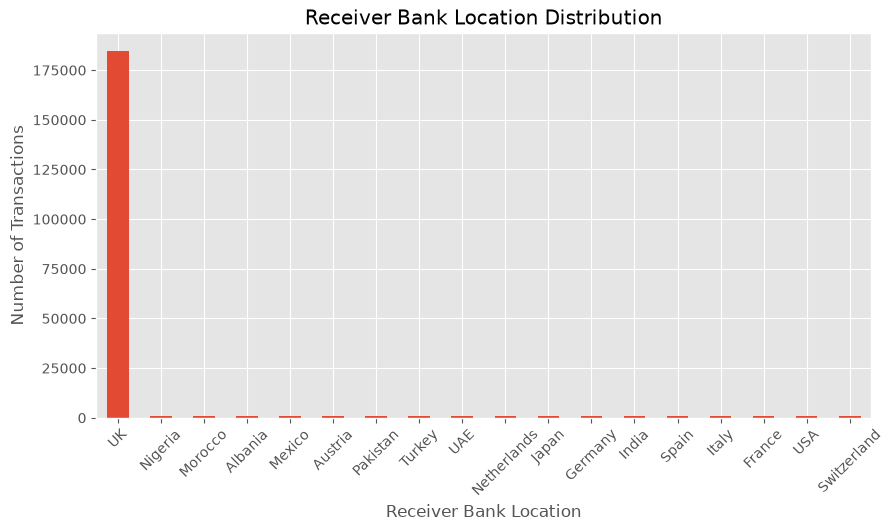

In [52]:
plt.figure(figsize=(10,5))

receiver_location.plot(
    kind="bar"
)

plt.title("Receiver Bank Location Distribution")
plt.xlabel("Receiver Bank Location")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.show()

**Observation**

Most transactions are received within a limited number of bank locations, indicating that financial activity is geographically concentrated.

In [53]:
(receiver_location / len(df) * 100).round(2)

Receiver_bank_location
UK             92.36
Nigeria         0.50
Morocco         0.50
Albania         0.50
Mexico          0.50
Austria         0.48
Pakistan        0.47
Turkey          0.46
UAE             0.45
Netherlands     0.45
Japan           0.44
Germany         0.43
India           0.43
Spain           0.41
Italy           0.41
France          0.41
USA             0.40
Switzerland     0.39
Name: count, dtype: float64

**Observation**

Only a few receiver locations account for the majority of financial transactions within the sampled dataset.

In [54]:
receiver_location_class = pd.crosstab(
    df["Receiver_bank_location"],
    df["Is_laundering"]
)

receiver_location_class

Is_laundering,0,1
Receiver_bank_location,,
Albania,759,235
Austria,813,154
France,739,82
Germany,766,102
India,719,137
Italy,693,131
Japan,792,83
Mexico,793,197
Morocco,748,253


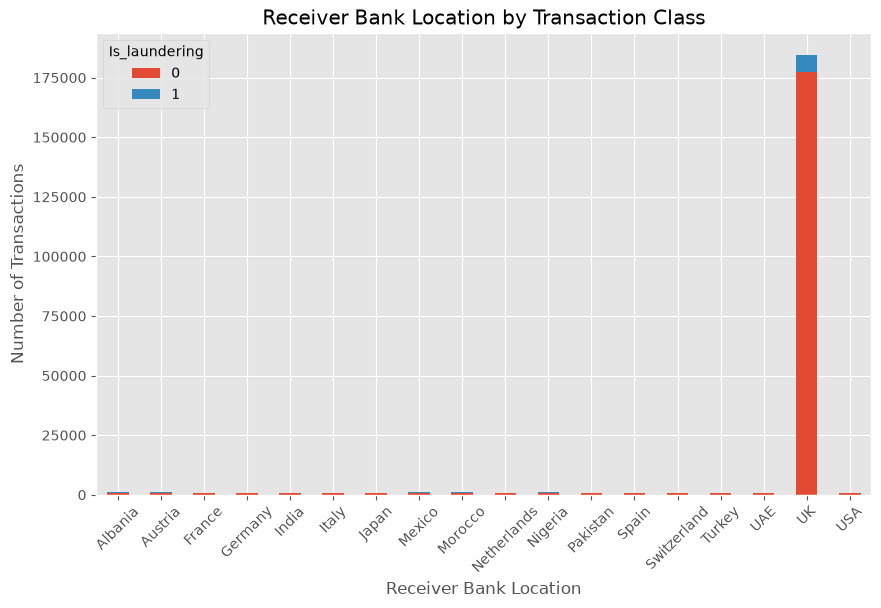

In [55]:
receiver_location_class.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Receiver Bank Location by Transaction Class")
plt.xlabel("Receiver Bank Location")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.show()

**Observation**

Although legitimate transactions dominate every receiver location, some locations contain relatively higher proportions of suspicious transactions that may contribute useful information for classification.

In [56]:
receiver_location_rate = (
    receiver_location_class.div(receiver_location_class.sum(axis=1), axis=0) * 100
).round(2)

receiver_location_rate

Is_laundering,0,1
Receiver_bank_location,,
Albania,76.36,23.64
Austria,84.07,15.93
France,90.01,9.99
Germany,88.25,11.75
India,84.00,16.00
Italy,84.10,15.90
Japan,90.51,9.49
Mexico,80.10,19.90
Morocco,74.73,25.27


**Observation**

The laundering rate provides a clearer comparison between receiver locations than transaction counts alone and may highlight locations associated with increased laundering activity.

## 5.12 Correlation Analysis

Correlation analysis helps identify relationships between numerical variables within the sampled dataset.

Although most variables are categorical, examining numerical correlations provides useful insights before feature engineering and model training.

In [59]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

numeric_df.corr()

,Sender_account,Receiver_account,Amount,Is_laundering
Sender_account,1.000000,-0.000037,-0.000192,0.010414
Receiver_account,-0.000037,1.000000,0.000119,-0.002916
Amount,-0.000192,0.000119,1.000000,0.071786
Is_laundering,0.010414,-0.002916,0.071786,1.000000


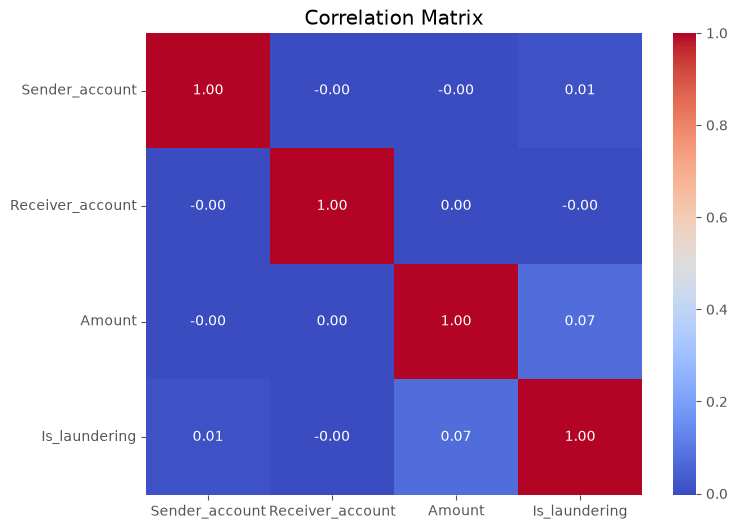

In [60]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

**Observation**

The numerical variables show relatively weak linear correlations with one another. This is expected because account identifiers function as unique identifiers rather than informative numerical values. Transaction amount exhibits only a weak relationship with the target variable, indicating that accurate money laundering detection will likely require combining multiple transaction characteristics rather than relying on a single feature.

# 6. Data Preprocessing

Before training machine learning models, the dataset must be prepared to ensure that all features are suitable for numerical algorithms.

This stage includes removing unnecessary variables, handling categorical features, engineering new variables, scaling numerical features, and splitting the data into training and testing sets.

These preprocessing steps improve model performance and ensure that the training process is both efficient and reproducible.

## 6.1 Load the Sample Dataset

The representative AML sample created during the sampling stage is loaded for preprocessing and model development.

In [61]:
import pandas as pd

df = pd.read_csv("AML_sample.csv")

df.head()

,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type
0,19:28:16,2023-05-09,371655141,8045939247,3792.25,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Small_Fan_Out
1,01:11:53,2023-08-01,1500297496,440699172,345.53,UK pounds,UK pounds,UK,UK,Credit card,0,Normal_Small_Fan_Out
2,11:19:15,2023-08-03,7775860537,7197849283,10128.69,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_Out
3,12:45:12,2023-06-09,3082029687,8404200332,18342.06,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Fan_In
4,04:44:01,2023-06-29,1179981989,8202066258,2345.67,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Group


In [62]:
df.shape

(199873, 12)

**Observation**

The sampled dataset contains approximately 200,000 transactions, making it computationally efficient while preserving all suspicious transactions from the original dataset.

## 6.2 Missing Value Analysis

Missing values may negatively affect machine learning algorithms. Therefore, the dataset is examined to verify whether any missing observations require treatment.

In [63]:
df.isnull().sum()

Time                      0
Date                      0
Sender_account            0
Receiver_account          0
Amount                    0
Payment_currency          0
Received_currency         0
Sender_bank_location      0
Receiver_bank_location    0
Payment_type              0
Is_laundering             0
Laundering_type           0
dtype: int64

In [65]:
(df.isnull().sum() / len(df) * 100).round(2)

Time                      0.0
Date                      0.0
Sender_account            0.0
Receiver_account          0.0
Amount                    0.0
Payment_currency          0.0
Received_currency         0.0
Sender_bank_location      0.0
Receiver_bank_location    0.0
Payment_type              0.0
Is_laundering             0.0
Laundering_type           0.0
dtype: float64

**Observation**

No missing values are present in the sampled dataset. Consequently, no imputation techniques are required before model training.

## 6.3 Feature Selection

Several variables are removed before model training because they either represent unique identifiers or introduce information leakage.

The variable **Laundering_type** is excluded because it directly describes the laundering category and would unrealistically reveal information about the target class.

In [66]:
df = df.drop(
    columns=[
        "Sender_account",
        "Receiver_account",
        "Laundering_type"
    ]
)

df.head()

,Time,Date,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering
0,19:28:16,2023-05-09,3792.25,UK pounds,UK pounds,UK,UK,ACH,0
1,01:11:53,2023-08-01,345.53,UK pounds,UK pounds,UK,UK,Credit card,0
2,11:19:15,2023-08-03,10128.69,UK pounds,UK pounds,UK,UK,ACH,0
3,12:45:12,2023-06-09,18342.06,UK pounds,UK pounds,UK,UK,Cheque,0
4,04:44:01,2023-06-29,2345.67,UK pounds,UK pounds,UK,UK,Cheque,0


## 6.4 Date and Time Processing

The original dataset contains separate date and time variables. Rather than using the raw values directly, additional temporal information is extracted to create more informative features for machine learning models.

In [67]:
df["Date"] = pd.to_datetime(df["Date"])

In [68]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Day_of_Week"] = df["Date"].dt.dayofweek

In [69]:
df["Hour"] = pd.to_datetime(
    df["Time"],
    format="%H:%M:%S"
).dt.hour

In [70]:
df[
    [
        "Date",
        "Time",
        "Year",
        "Month",
        "Day",
        "Day_of_Week",
        "Hour"
    ]
].head()

,Date,Time,Year,Month,Day,Day_of_Week,Hour
0,2023-05-09,19:28:16,2023,5,9,1,19
1,2023-08-01,01:11:53,2023,8,1,1,1
2,2023-08-03,11:19:15,2023,8,3,3,11
3,2023-06-09,12:45:12,2023,6,9,4,12
4,2023-06-29,04:44:01,2023,6,29,3,4


**Observation**

Several new temporal features were created from the original date and time variables. These features may help machine learning algorithms capture behavioural patterns related to transaction timing.

In [71]:
df = df.drop(
    columns=[
        "Date",
        "Time"
    ]
)

df.head()

,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Year,Month,Day,Day_of_Week,Hour
0,3792.25,UK pounds,UK pounds,UK,UK,ACH,0,2023,5,9,1,19
1,345.53,UK pounds,UK pounds,UK,UK,Credit card,0,2023,8,1,1,1
2,10128.69,UK pounds,UK pounds,UK,UK,ACH,0,2023,8,3,3,11
3,18342.06,UK pounds,UK pounds,UK,UK,Cheque,0,2023,6,9,4,12
4,2345.67,UK pounds,UK pounds,UK,UK,Cheque,0,2023,6,29,3,4


## 6.5 Encoding Categorical Variables

Machine learning algorithms require numerical input features. Therefore, all categorical variables are converted into numerical representations using Label Encoding.

Label Encoding assigns an integer value to each unique category while preserving all available information for model training.

In [72]:
from sklearn.preprocessing import LabelEncoder

In [73]:
df.dtypes

Amount                    float64
Payment_currency              str
Received_currency             str
Sender_bank_location          str
Receiver_bank_location        str
Payment_type                  str
Is_laundering               int64
Year                        int32
Month                       int32
Day                         int32
Day_of_Week                 int32
Hour                        int32
dtype: object

In [79]:
ccategorical_columns = df.select_dtypes(include=["object", "string"]).columns

In [75]:
encoder = LabelEncoder()

In [76]:
for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

In [77]:
df.head()

,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Year,Month,Day,Day_of_Week,Hour
0,3792.25,10,10,16,16,0,0,2023,5,9,1,19
1,345.53,10,10,16,16,4,0,2023,8,1,1,1
2,10128.69,10,10,16,16,0,0,2023,8,3,3,11
3,18342.06,10,10,16,16,3,0,2023,6,9,4,12
4,2345.67,10,10,16,16,3,0,2023,6,29,3,4


In [78]:
df.dtypes

Amount                    float64
Payment_currency            int64
Received_currency           int64
Sender_bank_location        int64
Receiver_bank_location      int64
Payment_type                int64
Is_laundering               int64
Year                        int32
Month                       int32
Day                         int32
Day_of_Week                 int32
Hour                        int32
dtype: object

**Observation**

All categorical variables have been successfully converted into numerical values using Label Encoding. The dataset now consists entirely of numerical features, making it suitable for machine learning algorithms.

## 6.6 Train-Test Split

Before training machine learning models, the dataset is divided into training and testing subsets.

The training set is used to build the models, while the testing set is reserved for evaluating model performance on previously unseen data.

A stratified split is applied to preserve the original class distribution in both subsets.

In [80]:
from sklearn.model_selection import train_test_split

In [81]:
X = df.drop("Is_laundering", axis=1)

y = df["Is_laundering"]

In [82]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [83]:
print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (159898, 11)
Testing set : (39975, 11)


In [84]:
print("Training target distribution")
print(y_train.value_counts())

print("\nTesting target distribution")
print(y_test.value_counts())

Training target distribution
Is_laundering
0    152000
1      7898
Name: count, dtype: int64

Testing target distribution
Is_laundering
0    38000
1     1975
Name: count, dtype: int64


In [85]:
print("Training (%)")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting (%)")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training (%)
Is_laundering
0    95.06
1     4.94
Name: proportion, dtype: float64

Testing (%)
Is_laundering
0    95.06
1     4.94
Name: proportion, dtype: float64


**Observation**

The dataset has been successfully divided into training and testing subsets using an 80/20 split.

Stratified sampling preserved the original class distribution in both subsets, ensuring that the machine learning models will be trained and evaluated on representative data.

## 6.7 Feature Scaling

Many machine learning algorithms perform better when numerical features are on a similar scale.

Standardization transforms numerical variables to have a mean of approximately 0 and a standard deviation of 1. This improves model convergence and prevents variables with larger numerical ranges from dominating the learning process.

Feature scaling is especially important for Logistic Regression and Support Vector Machine, while tree-based models such as Decision Trees and Random Forests are generally unaffected.

In [86]:
from sklearn.preprocessing import StandardScaler

In [87]:
numerical_features = [
    "Amount",
    "Year",
    "Month",
    "Day",
    "Day_of_Week",
    "Hour"
]

numerical_features

['Amount', 'Year', 'Month', 'Day', 'Day_of_Week', 'Hour']

In [88]:
scaler = StandardScaler()

In [89]:
X_train[numerical_features] = scaler.fit_transform(
    X_train[numerical_features]
)

X_test[numerical_features] = scaler.transform(
    X_test[numerical_features]
)

In [90]:
X_train.head()

,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Year,Month,Day,Day_of_Week,Hour
97522,-0.090617,10,10,16,16,6,-1.687617,1.373950,1.325640,1.527852,-0.546840
182352,0.001913,10,10,16,16,3,-1.687617,1.373950,-0.895497,-0.986350,0.853752
107759,-0.040922,10,10,16,16,3,0.592552,-1.460656,1.091836,-0.483510,-1.947432
3673,-0.096933,10,10,16,16,3,0.592552,-1.177195,-1.246203,1.527852,1.028826
174573,-0.096051,10,10,16,16,3,0.592552,-0.893735,-1.129301,-1.489190,1.203900


X_train[numerical_features].describe().round(2)

**Observation**

The numerical features were successfully standardized using StandardScaler.

Scaling was fitted only on the training data and then applied to the testing data, preventing information leakage.

The dataset is now fully preprocessed and ready for machine learning model training.

# 7. Model Development

This section trains and evaluates several supervised machine learning algorithms for detecting suspicious financial transactions.

Each model is trained using the same training dataset and evaluated on the same testing dataset to ensure a fair comparison.

The following algorithms are included:

- Logistic Regression
- Decision Tree
- Random Forest
- Support Vector Machine (SVM)

Model performance is evaluated using several classification metrics, including Accuracy, Precision, Recall, F1-score and ROC-AUC.

## 7.1 Logistic Regression

Logistic Regression is one of the most widely used binary classification algorithms.

It estimates the probability that a transaction belongs to the positive class (money laundering) using a logistic function.

Although relatively simple, Logistic Regression often performs well on structured tabular datasets and serves as an important baseline model for comparison.

In [93]:
from sklearn.linear_model import LogisticRegression

In [94]:
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [95]:
logistic_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [96]:
y_pred_lr = logistic_model.predict(X_test)

In [97]:
y_prob_lr = logistic_model.predict_proba(X_test)[:,1]

### Model Evaluation

In [98]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [99]:
print("Accuracy :", round(accuracy_score(y_test, y_pred_lr),4))
print("Precision:", round(precision_score(y_test, y_pred_lr),4))
print("Recall   :", round(recall_score(y_test, y_pred_lr),4))
print("F1-score :", round(f1_score(y_test, y_pred_lr),4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_lr),4))

Accuracy : 0.9506
Precision: 0.5
Recall   : 0.0061
F1-score : 0.012
ROC-AUC  : 0.6703


In [100]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

cm

array([[37988,    12],
       [ 1963,    12]])

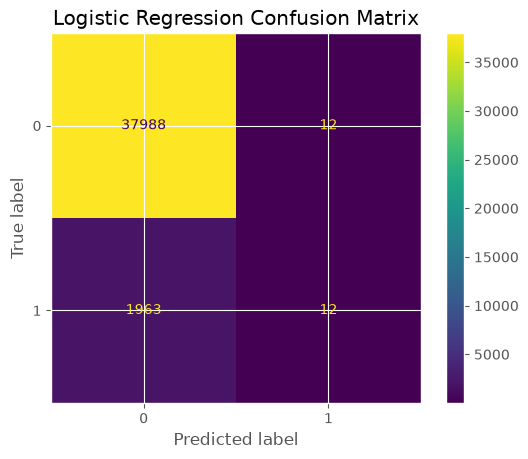

In [101]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(cm).plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [102]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97     38000
           1       0.50      0.01      0.01      1975

    accuracy                           0.95     39975
   macro avg       0.73      0.50      0.49     39975
weighted avg       0.93      0.95      0.93     39975



### Observation

Logistic Regression achieved an overall accuracy of approximately 95%, mainly because legitimate transactions dominate the dataset.

However, the model detected only a very small proportion of laundering transactions, resulting in extremely low recall and F1-score.

This indicates that Logistic Regression struggles to identify the minority class despite the sampling strategy and therefore serves primarily as a baseline model for comparison with more advanced algorithms.

## 7.2 Decision Tree

Decision Trees classify observations by recursively splitting the data into smaller subsets based on feature values.

Unlike Logistic Regression, Decision Trees can capture non-linear relationships and interactions between variables without requiring feature scaling.

This model is particularly useful for detecting complex behavioural patterns that may occur in suspicious financial transactions.

In [103]:
from sklearn.tree import DecisionTreeClassifier

In [104]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)

In [105]:
decision_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [106]:
y_pred_dt = decision_tree.predict(X_test)

In [107]:
y_prob_dt = decision_tree.predict_proba(X_test)[:,1]

### Model Evaluation

In [108]:
print("Accuracy :", round(accuracy_score(y_test, y_pred_dt),4))
print("Precision:", round(precision_score(y_test, y_pred_dt),4))
print("Recall   :", round(recall_score(y_test, y_pred_dt),4))
print("F1-score :", round(f1_score(y_test, y_pred_dt),4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_dt),4))

Accuracy : 0.9171
Precision: 0.2159
Recall   : 0.2577
F1-score : 0.2349
ROC-AUC  : 0.6045


In [109]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

cm_dt

array([[36151,  1849],
       [ 1466,   509]])

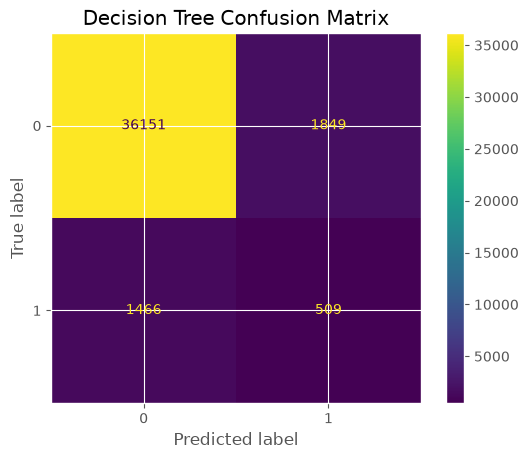

In [110]:
ConfusionMatrixDisplay(cm_dt).plot()

plt.title("Decision Tree Confusion Matrix")

plt.show()

In [111]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.96      0.95      0.96     38000
           1       0.22      0.26      0.23      1975

    accuracy                           0.92     39975
   macro avg       0.59      0.60      0.60     39975
weighted avg       0.92      0.92      0.92     39975



### Observation

Compared with Logistic Regression, the Decision Tree detects substantially more laundering transactions, resulting in a much higher recall and F1-score.

Although the overall accuracy is slightly lower, the model provides a better balance between identifying suspicious transactions and maintaining acceptable classification performance.

These results suggest that Decision Trees are more suitable for capturing the non-linear patterns present in financial transaction data.

## 7.3 Random Forest

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to improve prediction accuracy and reduce overfitting.

Each tree is trained using a random subset of the training data and features. The final prediction is obtained through majority voting across all trees.

Random Forest is widely used in fraud detection and Anti-Money Laundering because it can model complex relationships while remaining robust to noisy data.

In [112]:
from sklearn.ensemble import RandomForestClassifier

In [113]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [114]:
random_forest.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [115]:
y_pred_rf = random_forest.predict(X_test)

In [116]:
y_prob_rf = random_forest.predict_proba(X_test)[:,1]

### Model Evaluation

In [117]:
print("Accuracy :", round(accuracy_score(y_test, y_pred_rf),4))
print("Precision:", round(precision_score(y_test, y_pred_rf),4))
print("Recall   :", round(recall_score(y_test, y_pred_rf),4))
print("F1-score :", round(f1_score(y_test, y_pred_rf),4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_rf),4))

Accuracy : 0.9539
Precision: 0.6415
Recall   : 0.1504
F1-score : 0.2436
ROC-AUC  : 0.7855


In [118]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

cm_rf

array([[37834,   166],
       [ 1678,   297]])

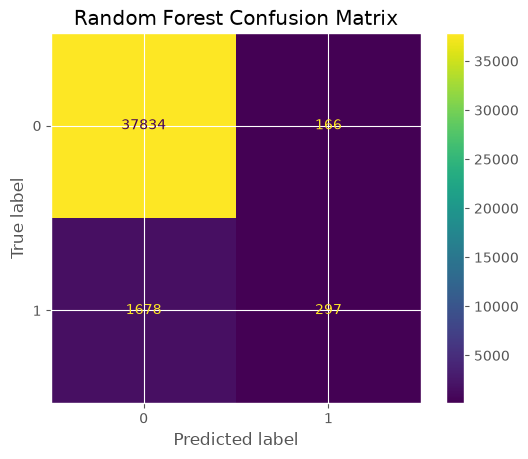

In [119]:
ConfusionMatrixDisplay(cm_rf).plot()

plt.title("Random Forest Confusion Matrix")

plt.show()

In [120]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98     38000
           1       0.64      0.15      0.24      1975

    accuracy                           0.95     39975
   macro avg       0.80      0.57      0.61     39975
weighted avg       0.94      0.95      0.94     39975



### Observation

Random Forest combines multiple decision trees to produce more stable and accurate predictions than a single Decision Tree.

Its ensemble structure generally improves the detection of suspicious transactions while reducing the risk of overfitting.

The evaluation metrics obtained in this section will be compared with the other machine learning models to identify the best-performing classifier for AML transaction detection.